In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve, roc_auc_score

In [3]:
# Load the dataset

df = pd.read_csv("/content/diabetic_data.csv")

print("Dataset shape:", df.shape)
print("\nSample records:")
display(df.head())

Dataset shape: (101766, 50)

Sample records:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
# Data cleaning

df = df.replace("?", np.nan)

print("Missing values in each column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("\nData types:")
print(df.dtypes)

print("\nOriginal target distribution:")
print(df["readmitted"].value_counts())

Missing values in each column:
encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride      

In [5]:
# Convert the target into binary values
# 0 -> patient was not readmitted
# 1 -> patient was readmitted

target = df["readmitted"].map({
    "NO": 0,
    ">30": 1,
    "<30": 1
})

features = df.drop(columns=["readmitted"])

print("Number of input features:", features.shape[1])

print("\nBinary target distribution:")
print(target.value_counts())

Number of input features: 49

Binary target distribution:
readmitted
0    54864
1    46902
Name: count, dtype: int64


In [6]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.20,
    random_state=42,
    stratify=target
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (81412, 49)
Testing set : (20354, 49)


In [7]:
# Identify numerical and categorical columns

num_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

cat_cols = X_train.select_dtypes(
    include=["object"]
).columns

print("Numerical columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))

Numerical columns: 13
Categorical columns: 36


In [8]:
# Preprocessing for numerical data

num_pipeline = Pipeline([
    ("fill_missing", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler())
])

# Preprocessing for categorical data

cat_pipeline = Pipeline([
    ("fill_missing", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both preprocessing pipelines

data_processor = ColumnTransformer([
    ("numerical", num_pipeline, num_cols),
    ("categorical", cat_pipeline, cat_cols)
])

# Fit preprocessing only on training data

X_train_ready = data_processor.fit_transform(X_train)

# Apply the same transformation to test data

X_test_ready = data_processor.transform(X_test)

print("Processed training shape:", X_train_ready.shape)
print("Processed testing shape :", X_test_ready.shape)

Processed training shape: (81412, 2387)
Processed testing shape : (20354, 2387)


In [9]:
# Logistic Regression without regularization

lr_no_regularization = LogisticRegression(
    penalty=None,
    max_iter=1000,
    random_state=42
)

lr_no_regularization.fit(
    X_train_ready,
    y_train
)

pred_no_reg = lr_no_regularization.predict(X_test_ready)

prob_no_reg = lr_no_regularization.predict_proba(
    X_test_ready
)[:, 1]

In [10]:
# Evaluation without L2

accuracy_no_reg = accuracy_score(
    y_test,
    pred_no_reg
)

auc_no_reg = roc_auc_score(
    y_test,
    prob_no_reg
)

print("Accuracy without L2:", round(accuracy_no_reg, 4))
print("AUC without L2:", round(auc_no_reg, 4))

print("\nClassification Report:")
print(classification_report(y_test, pred_no_reg))

Accuracy without L2: 0.6354
AUC without L2: 0.6745

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.73      0.68     10973
           1       0.62      0.53      0.57      9381

    accuracy                           0.64     20354
   macro avg       0.63      0.63      0.63     20354
weighted avg       0.63      0.64      0.63     20354



In [11]:
# Logistic Regression with L2 regularization

lr_l2 = LogisticRegression(
    penalty="l2",
    C=1.0,
    max_iter=1000,
    random_state=42
)

lr_l2.fit(
    X_train_ready,
    y_train
)

pred_l2 = lr_l2.predict(X_test_ready)

prob_l2 = lr_l2.predict_proba(
    X_test_ready
)[:, 1]

In [12]:
# Evaluation with L2

accuracy_l2 = accuracy_score(
    y_test,
    pred_l2
)

auc_l2 = roc_auc_score(
    y_test,
    prob_l2
)

print("Accuracy with L2:", round(accuracy_l2, 4))
print("AUC with L2:", round(auc_l2, 4))

print("\nClassification Report:")
print(classification_report(y_test, pred_l2))

Accuracy with L2: 0.6389
AUC with L2: 0.6805

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.74      0.69     10973
           1       0.63      0.52      0.57      9381

    accuracy                           0.64     20354
   macro avg       0.64      0.63      0.63     20354
weighted avg       0.64      0.64      0.63     20354



In [13]:
# Calculate ROC curves

fpr_no_reg, tpr_no_reg, _ = roc_curve(
    y_test,
    prob_no_reg
)

fpr_l2, tpr_l2, _ = roc_curve(
    y_test,
    prob_l2
)

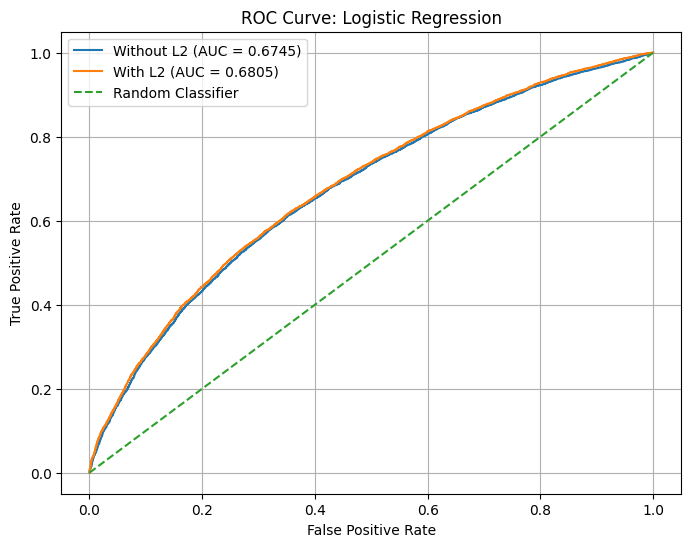

In [14]:
# Plot both ROC curves

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_no_reg,
    tpr_no_reg,
    label=f"Without L2 (AUC = {auc_no_reg:.4f})"
)

plt.plot(
    fpr_l2,
    tpr_l2,
    label=f"With L2 (AUC = {auc_l2:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Logistic Regression")
plt.legend()
plt.grid()

plt.show()

In [15]:
# Compare the AUC values

print("\n" + "=" * 35)
print("AUC COMPARISON")
print("=" * 35)

print(f"Without L2 : {auc_no_reg:.4f}")
print(f"With L2    : {auc_l2:.4f}")


AUC COMPARISON
Without L2 : 0.6745
With L2    : 0.6805
